In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('compressed_data.csv', low_memory = False )

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [87]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,year,month
count,8.667500e+04,8.667500e+04,86668.000000,86668.000000,86675.000000,86675.000000,86675.0,86675.000000,86675.000000,86675,86675.000000,86387.000000,86415.000000,86496.000000,86675.000000,86675.000000
mean,2.944546e+07,4.919344e+10,40.727427,-73.948569,2012.486681,624.622267,124.855806,7.446772,32.435039,2019-06-11 21:01:39.059706112,1.374114,3.278989,7.030678,142.059748,2018.996181,5.902025
min,1.001254e+06,1.236005e+08,40.504560,-74.249840,2003.000000,0.000000,0.0,-365.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000,2012.000000,1.000000
25%,1.529486e+07,2.447265e+10,40.687690,-73.982150,2008.000000,338.000000,68.0,2.000000,3.000000,2018-10-28 00:00:00,0.220000,2.000000,1.000000,6.000000,2018.000000,4.000000
50%,3.069906e+07,4.903955e+10,40.721380,-73.953750,2012.000000,623.000000,125.0,3.000000,11.000000,2019-06-14 00:00:00,0.740000,3.000000,1.000000,101.000000,2019.000000,6.000000
75%,4.320147e+07,7.386021e+10,40.762630,-73.930970,2017.000000,913.000000,183.0,5.000000,39.000000,2019-07-05 00:00:00,2.000000,4.000000,2.000000,267.000000,2019.000000,7.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.0,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,3677.000000,2022.000000,12.000000
std,1.627408e+07,2.852779e+10,0.056338,0.050309,5.758416,332.607452,66.535456,27.918643,52.265110,NaN,1.746928,1.283478,29.376185,133.936379,1.661649,3.025074


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [6]:
df.drop(columns = ['house_rules', 'license'], inplace = True)

In [7]:
df['neighbourhood group'].replace({'brookln': 'Brooklyn', 'manhatan': 'Manhattan'}, inplace = True)

In [8]:
df['last review'] = pd.to_datetime(df['last review'])
df['year'] = df['last review'].dt.year
df = df[df['year'] <= 2023]

# Handling null values

In [9]:
df['last review'].fillna(df['last review'].min(), inplace =True)

In [10]:
df['reviews per month'].fillna(0, inplace = True)

In [11]:
df['service fee'] = (df['service fee'].str.replace('$', '', regex = False)).astype('Int64')

In [12]:
df['price'] = pd.to_numeric(
    df['price'].str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86701 entries, 0 to 102597
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              86701 non-null  int64         
 1   NAME                            86488 non-null  object        
 2   host id                         86701 non-null  int64         
 3   host_identity_verified          86455 non-null  object        
 4   host name                       86375 non-null  object        
 5   neighbourhood group             86676 non-null  object        
 6   neighbourhood                   86685 non-null  object        
 7   lat                             86694 non-null  float64       
 8   long                            86694 non-null  float64       
 9   country                         86212 non-null  object        
 10  country code                    86585 non-null  object        
 11  instan

In [14]:
df.fillna({'price': 0, 'service fee': 0}, inplace = True)

In [15]:
df.drop(df[(df['price'] == 0) & (df['service fee'] == 0)].index , inplace = True)

In [16]:
df.isnull().sum()

id                                  0
NAME                              213
host id                             0
host_identity_verified            246
host name                         322
neighbourhood group                25
neighbourhood                      16
lat                                 7
long                                7
country                           489
country code                      116
instant_bookable                   93
cancellation_policy                67
room type                           0
Construction year                 183
price                               0
service fee                         0
minimum nights                    344
number of reviews                  59
last review                         0
reviews per month                   0
review rate number                288
calculated host listings count    260
availability 365                  179
year                                0
dtype: int64

In [113]:
df.fillna({
    'Construction year': df['Construction year'].mean(), 
    'minimum nights': 0, 
    'number of reviews': 0,
    'availability 365': 0,
    'host_identity_verified': 'Verification not done'}, inplace = True)  

# Exploratory Data Analysis

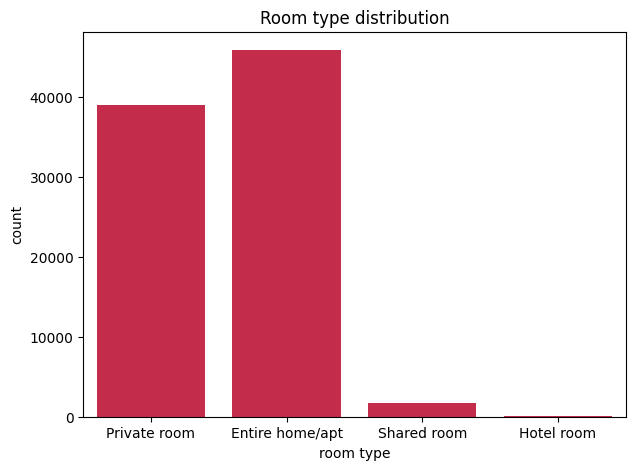

In [18]:
plt.figure(figsize= (7,5))
sns.countplot(x = 'room type', data = df, color = 'crimson')
plt.title('Room type distribution')
plt.show()

### Mostly sold property in airbnb is entire home or apartment

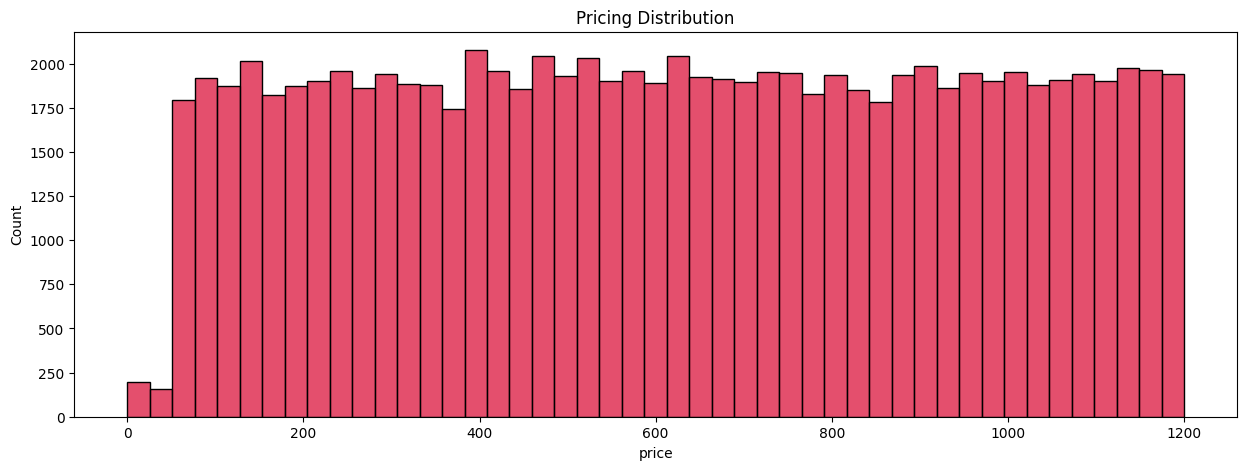

In [60]:
plt.figure(figsize= (15,5))
sns.histplot(df['price'], color = 'crimson')
# plt.axhline(df['price'].mean(), linestyle = '--')
plt.title('Pricing Distribution')
plt.show()

### Price distribution is somewhere constant

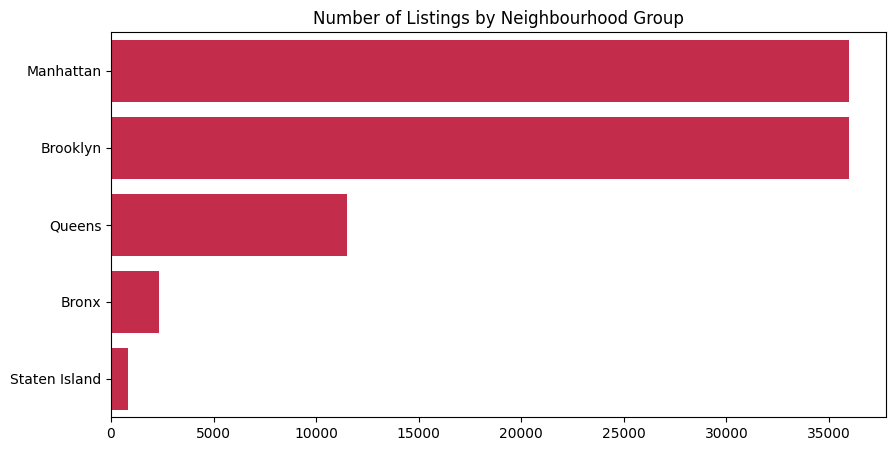

In [21]:
plt.figure(figsize= (10,5))
sns.countplot(df['neighbourhood group'],color = 'crimson', order = df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighbourhood Group')
plt.ylabel('')
plt.xlabel('')
plt.show()

### From the above chart , most famous cities are (Manhattan and Brooklyn)

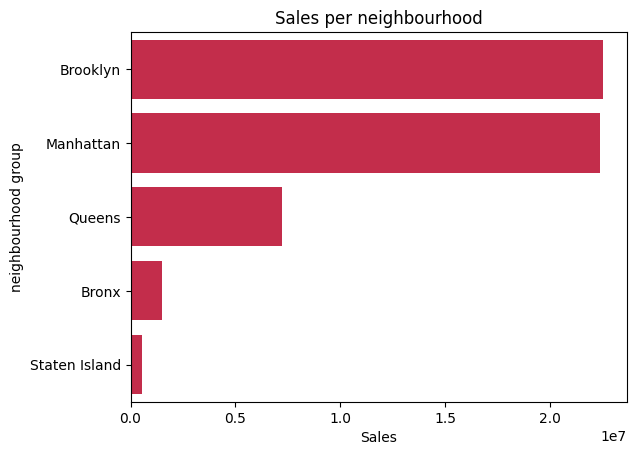

In [77]:
# Total revenue by area

data = df.groupby('neighbourhood group', as_index = False)['price'].sum().sort_values(by= 'price' , ascending =False)
sns.barplot(y = 'neighbourhood group', x = 'price', data = data, color = 'crimson')
plt.title('Sales per neighbourhood')
plt.xlabel('Sales')
plt.show()

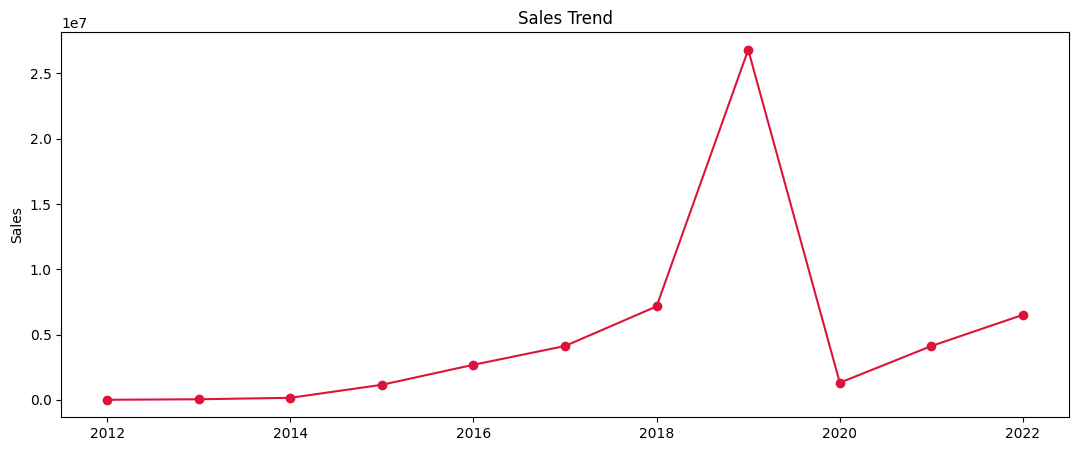

In [50]:
plt.figure(figsize= (13,5))
data = df.groupby('year')['price'].sum().reset_index()
plt.plot(data['year'], data['price'], color = 'crimson', marker = 'o')
plt.title('Sales Trend')
plt.ylabel('Sales')
plt.xlabel('')
plt.show()

### Through the sales trend we can see a sharp decent in year 2020. It may be due to covid-19 and after that the sales can be seen increasing

Text(0.5, 0, 'Host Verification Type')

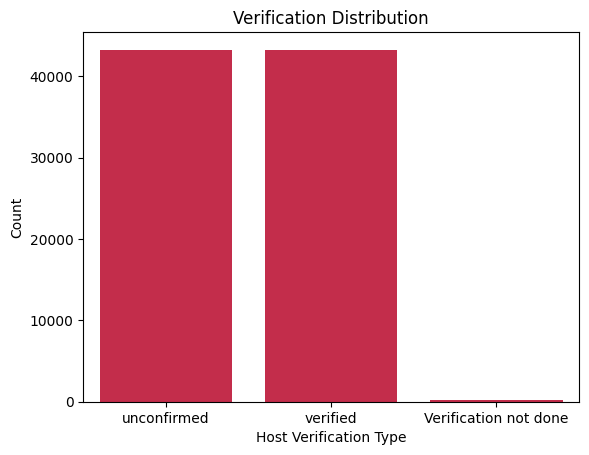

In [41]:
data = df['host_identity_verified'].value_counts().reset_index()
sns.barplot(data = data, x = 'host_identity_verified', y = 'count',  color = 'crimson')
plt.title('Verification Distribution')
plt.ylabel('Count')
plt.xlabel('Host Verification Type')

### As we can see through the distrubution, we need to make more hosts identity confirmed.

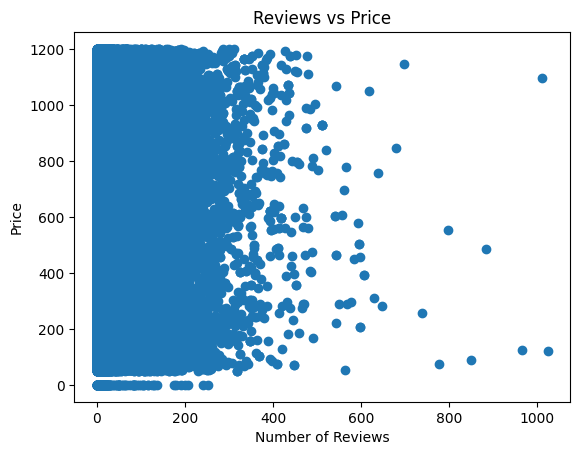

In [56]:
plt.scatter(df['number of reviews'], df['price'])
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.title('Reviews vs Price')
plt.show()

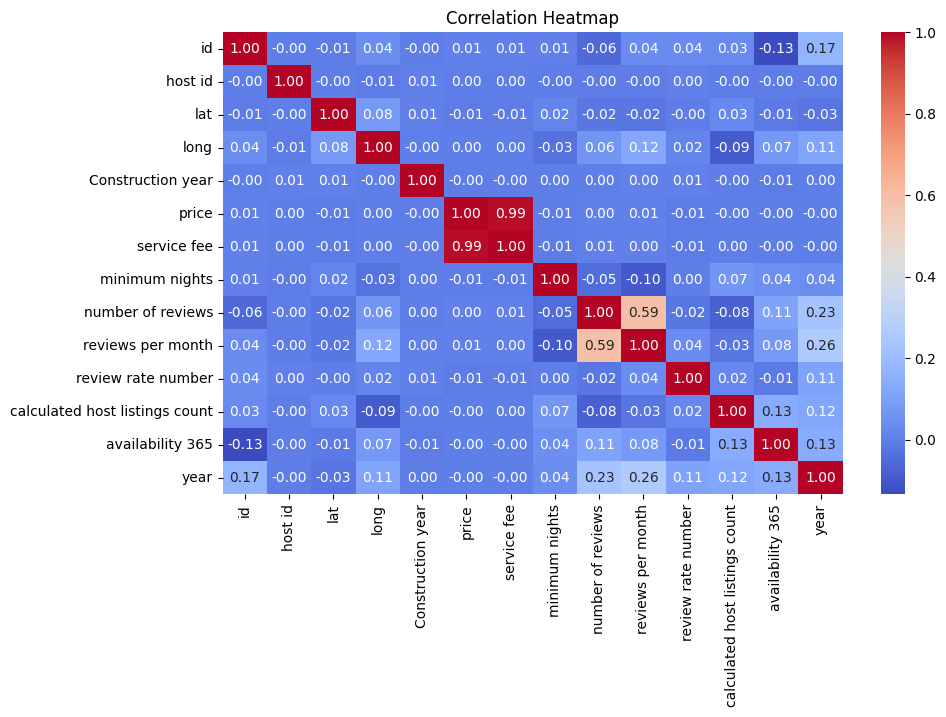

In [57]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### Using heatmap we can say that (Higher the price , higher will be the service fee)

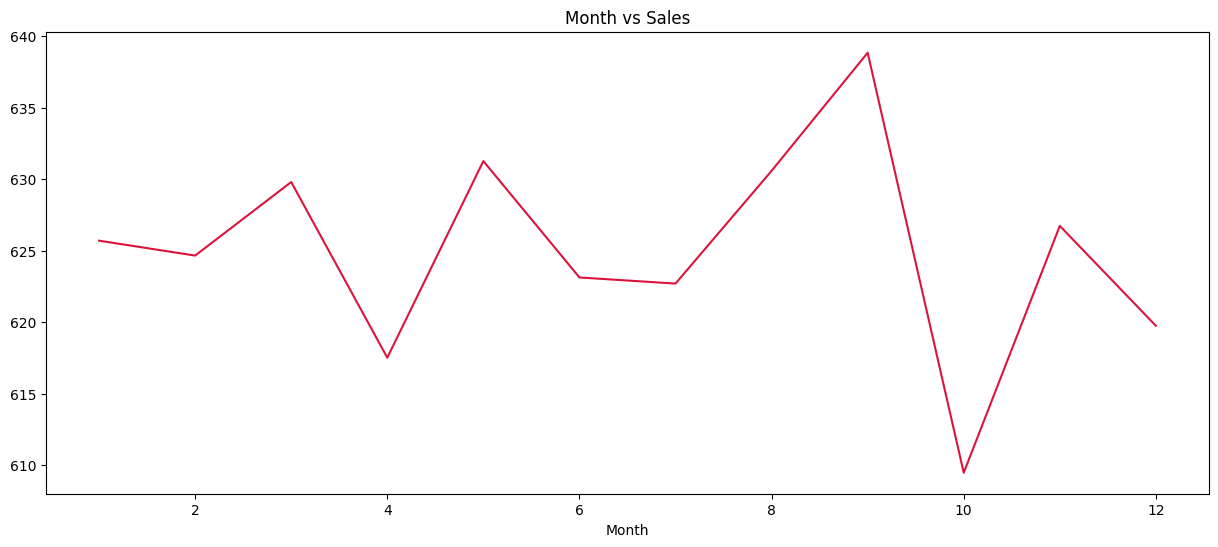

In [100]:
df['month'] = df['last review'].dt.month

plt.figure(figsize=(15,6))
data = df.groupby('month', as_index = False)['price'].mean()
# plt.axhline(df['price'].mean(), linestyle = '-')
plt.plot(data['month'], data['price'], color = 'crimson')
plt.title('Month vs Sales')
plt.xlabel('Month')
plt.show()

In [96]:
df['price_category'] = pd.cut(
    df['price'], 
    bins = [0,100,300,600,1000,5000],
    labels = ['budget', 'mid', 'premium', 'luxury', 'ultra']
)

C:\Users\eshuk\AppData\Local\Temp\ipykernel_16140\2761693156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = df.groupby('price_category', as_index = False)['price'].sum()


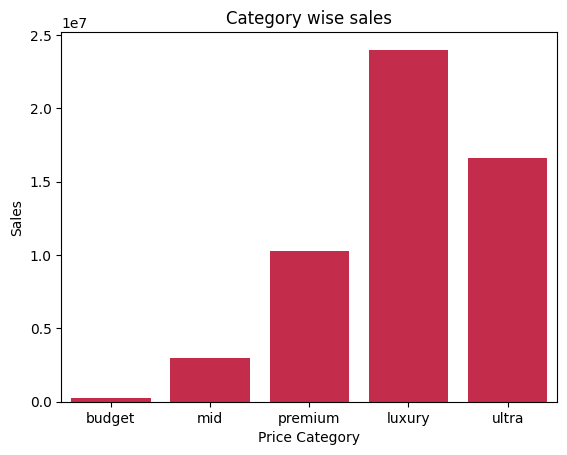

In [104]:
data = df.groupby('price_category', as_index = False)['price'].sum()
sns.barplot(data = data, x = 'price_category', y = 'price',  color = 'crimson')
plt.title('Category wise sales')
plt.xlabel('Price Category')
plt.ylabel('Sales')
plt.show()

### luxury category contributes to major revenue

# Booking Demand Prediction Model

#### high vs low demand

In [105]:
df['high_demand'] = df['number of reviews'].apply(lambda x: 1 if x > df['number of reviews'].median() else 0)

In [135]:
# Selecting Features

features = df[['price', 'minimum nights', 'availability 365', 'reviews per month']]
target = df['high_demand']

In [136]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [137]:
# Train model (logistic regression)

lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [138]:
# train model (Random Forest Classifier)

rf = RandomForestClassifier(n_estimators = 200, random_state = 42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [139]:
# Evaluate

pred = lr.predict(X_test)
pred_rf = rf.predict(X_test)
print('Accuracy LR: ', accuracy_score(y_test, pred))
print('Accuracy RF: ', accuracy_score(y_test, pred_rf))

Accuracy LR:  0.763945774444765
Accuracy RF:  0.8734352466109028


### Using random forest classifier model, we got 87% accuracy for our Booking Demand Model.

#### 1. Highlight high demand homes.
#### 2. Forecast bookings.
#### 3. Lower price if predicted low demand and vice-versa.

# **Conclusion**

### This Airbnb exploratory data analysis revealed clear pricing trends, location performace, and demand across different room-types and neighbourhood. While the Booking Demand Model helps us know the high demand listings, which will help in increasing the revenue.